In [62]:
import pandas as pd
from datasets import Dataset, DatasetDict
from transformers import AutoTokenizer, CamembertModel, TrainingArguments, Trainer,CamembertForSequenceClassification,CamembertTokenizer,AutoModelForSequenceClassification
import torch
import torch.nn as nn
import ast
import numpy as np
from sklearn.neural_network import MLPClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, hamming_loss,accuracy_score
import re
from bs4 import BeautifulSoup
from openai import OpenAI
import openai
import os
import asyncio
from collections import defaultdict
import random
from torch.nn.functional import cosine_similarity


In [ ]:
#YOUR_KEY = 
#client = openai.OpenAI(api_key=)

# Define the coroutine for making API calls to GPT
def make_api_call_to_gpt(prompt, model="gpt-4.1-nano"):
    messages = [{"role": "user", "content": prompt}]
    response = client.chat.completions.create(
        model=model,
        messages=messages,
        temperature=0,
        max_tokens=500,
    )
    
    return response.choices[0].message.content

***
**Data import and cleaning**
***

In [41]:
df_text = pd.read_excel('withtext.xlsx')
df_text = df_text.dropna(subset=['text'])

In [42]:
df = pd.read_csv("without_text_uniquerater.csv")
df = df.merge(df_text[['URL', 'text','Title']], on='URL', how='left')
#Merge Title and text into column text by putting Title, adding a space and then adding text
df['text'] = 'Titre :' + df['Title'] + ' texte :' + df['text']
def minimal_cleaning(text):
    soup = BeautifulSoup(text, "html.parser")
    clean_text = soup.get_text(separator=" ")
    clean_text = re.sub(r"http\S+|www\.\S+", "", clean_text)
    clean_text = re.sub(r'\s+', ' ', clean_text).strip()
    return clean_text
df['text'] = df['text'].apply(minimal_cleaning)
dataset = Dataset.from_pandas(df)

In [43]:
split_dataset = dataset.train_test_split(test_size=0.4, seed=42)
test_valid = split_dataset['test'].train_test_split(test_size=0.5, seed=42)
dataset_dict = DatasetDict({
    'train': split_dataset['train'],
    'validation': test_valid['train'],
    'test': test_valid['test']
})
print(dataset_dict)

DatasetDict({
    train: Dataset({
        features: ['URL', 'Fake News', 'Opinions', 'Subjective', 'Reported information', 'Sources Cited', 'False Information', 'Insinuation', 'Exaggeration', 'Offbeat Title', 'text', 'Title'],
        num_rows: 55
    })
    validation: Dataset({
        features: ['URL', 'Fake News', 'Opinions', 'Subjective', 'Reported information', 'Sources Cited', 'False Information', 'Insinuation', 'Exaggeration', 'Offbeat Title', 'text', 'Title'],
        num_rows: 19
    })
    test: Dataset({
        features: ['URL', 'Fake News', 'Opinions', 'Subjective', 'Reported information', 'Sources Cited', 'False Information', 'Insinuation', 'Exaggeration', 'Offbeat Title', 'text', 'Title'],
        num_rows: 19
    })
})


In [44]:
labels_name = ['Fake News', 'Opinions', 'Subjective', 'Reported information','Sources Cited', 'False Information', 'Insinuation', 'Exaggeration','Offbeat Title']
id2label = {idx:label for idx, label in enumerate(labels_name)}
label2id = {label:idx for idx, label in enumerate(labels_name)}
labels = ['Fake News', 'Opinions', 'Subjective', 'Reported information','Sources Cited', 'False Information', 'Insinuation', 'Exaggeration','Offbeat Title']

In [45]:
tokenizer = AutoTokenizer.from_pretrained("almanach/camembert-base")

def preprocess_data(dataset):
  text = dataset["text"]
  encoding = tokenizer(text, padding="longest", truncation=True, max_length=512)
  print(encoding)
  # add labels
  labels_batch = {k: dataset[k] for k in dataset.keys() if k in labels}
  # create numpy array of shape (batch_size, num_labels)
  labels_matrix = np.zeros((len(text), len(labels)))
  # fill numpy array
  for idx, label in enumerate(labels):
    labels_matrix[:, idx] = labels_batch[label]

  encoding["labels"] = labels_matrix.tolist()
  
  return encoding

In [ ]:
encoded_dataset = dataset_dict.map(preprocess_data, batched=True, remove_columns=dataset_dict['train'].column_names)

In [47]:
encoded_dataset.set_format("torch")

In [48]:
pos_counts = df[labels_name].sum(axis=0).values 
total_samples = len(df[labels])  # total nuµmber of instances in your dataset
neg_counts = total_samples - pos_counts  # corresponding negative sample counts
pos_weight = neg_counts / (pos_counts + 1e-5)  # adding a small epsilon to avoid division by zero
pos_weight = torch.tensor(pos_weight, dtype=torch.float)

***
**MLP**
***

In [49]:
class BertMLPClassifier(nn.Module):
    def __init__(self, num_labels, bert_model_name="almanach/camembert-base", mlp_hidden_dim=256, dropout_rate=0.1):
        super(BertMLPClassifier, self).__init__()

        self.bert = CamembertModel.from_pretrained(bert_model_name)
        self.dropout = nn.Dropout(dropout_rate)
        self.mlp = nn.Sequential(
            nn.Linear(self.bert.config.hidden_size, mlp_hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(mlp_hidden_dim, num_labels)  # Note: output dimension equals number of labels
        )
    
    def forward(self, input_ids, attention_mask, labels=None):
        # Get BERT's outputs (pooled_output corresponds to [CLS] token representation)
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = outputs.pooler_output  # shape: (batch_size, hidden_size)
        pooled_output = self.dropout(pooled_output)
        
        logits = self.mlp(pooled_output)  # shape: (batch_size, num_labels)
        
        loss = None
        if labels is not None:
            loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
            loss = loss_fn(logits, labels.float())
            
        return {"loss": loss, "logits": logits}

num_labels = len(labels_name)  
model = BertMLPClassifier(num_labels=num_labels)

In [50]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probabilities = 1 / (1 + np.exp(-logits))
    predictions = (probabilities > 0.5).astype(int)
    subset_accuracy = np.mean(np.all(predictions == labels, axis=1))
    return {"subset_accuracy": subset_accuracy}

In [51]:
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=10,
    per_device_train_batch_size=4,
    learning_rate=2e-5,
    per_device_eval_batch_size=4,
    eval_strategy="epoch",
    logging_strategy="steps",
    logging_steps=10,
    save_strategy="epoch",
    load_best_model_at_end=True,
)
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=encoded_dataset['train'],
    eval_dataset=encoded_dataset['validation'],
    compute_metrics=compute_metrics,  # Now Trainer will compute our defined metrics
)
trainer.train()

Epoch,Training Loss,Validation Loss,Subset Accuracy
1,0.722300,0.689588,0.000000
2,0.803700,0.689711,0.000000
3,0.725200,0.689314,0.000000
4,0.677200,0.688797,0.000000
5,0.734500,0.688614,0.000000
6,0.699800,0.687803,0.000000
7,0.796400,0.686868,0.000000
8,0.727200,0.685889,0.000000
9,0.704100,0.685605,0.000000
10,0.694100,0.685302,0.000000


TrainOutput(global_step=140, training_loss=0.7238742862428937, metrics={'train_runtime': 862.2496, 'train_samples_per_second': 0.638, 'train_steps_per_second': 0.162, 'total_flos': 0.0, 'train_loss': 0.7238742862428937, 'epoch': 10.0})

In [189]:
results = trainer.evaluate(encoded_dataset["test"])
print("Validation Metrics:", results)

Validation Metrics: {'eval_loss': 0.5323321223258972, 'eval_subset_accuracy': 0.13157894736842105, 'eval_runtime': 14.1937, 'eval_samples_per_second': 2.677, 'eval_steps_per_second': 0.705, 'epoch': 10.0}


In [ ]:
pred_output = trainer.predict(encoded_dataset['test'])
logits = pred_output.predictions
probabilities = 1 / (1 + np.exp(-logits))
threshold = 0.5
y_pred = (probabilities > threshold).astype(int)
print("Predicted Labels (y_pred) for the validation set:")
print(y_pred)

In [ ]:
pred_output = trainer.predict(encoded_dataset['test'])
logits = pred_output.predictions
print("Raw logits:\n", logits)

In [53]:
y_true = encoded_dataset['test']['labels']
# Assuming y_true and y_pred are your true and predicted multi-hot label vectors
micro_f1 = f1_score(y_true, y_pred, average="micro")
macro_f1 = f1_score(y_true, y_pred, average="macro")
ham_loss = hamming_loss(y_true, y_pred)

print("Micro F1 Score:", micro_f1)
print("Macro F1 Score:", macro_f1)
print("Hamming Loss:", ham_loss)


Micro F1 Score: 0.5061728395061729
Macro F1 Score: 0.4552551455364755
Hamming Loss: 0.4678362573099415


***
**Data augmentation**
***

In [ ]:
English_version_table = []
for val in df['text']:
    prompt = f" Translate the following text to english : {val}"
    English_version = make_api_call_to_gpt(prompt)
    English_version_table.append(English_version)

English_version_table

In [166]:
df['English_version'] = English_version_table
df.to_csv('translated.csv', index=False)

In [ ]:
French_version_table = []
for val in df['English_version']:
    prompt = f" Translate the following text to french : {val}"
    French_version = make_api_call_to_gpt(prompt)
    French_version_table.append(French_version)

French_version_table

In [169]:
df['French_version'] = French_version_table
df.to_csv('translated.csv', index=False)

In [ ]:
df = pd.read_csv('translated.csv')
tokenizer = AutoTokenizer.from_pretrained('almanach/camembert-base')
model = CamembertModel.from_pretrained('almanach/camembert-base')


def get_embeddings(texts):
    embeddings = []
    for text in texts:
        inputs = tokenizer(text, return_tensors='pt', truncation=True, padding=True)
        outputs = model(**inputs)
        cls_embedding = outputs.last_hidden_state[:, 0, :]  # CLS token
        embeddings.append(cls_embedding.detach().numpy().squeeze())
    return torch.tensor(embeddings)


# Original French and Augmented French
original_texts = df['text'].tolist()
translated_texts = df['French_version'].tolist()
original_embeddings = get_embeddings(original_texts)
translated_embeddings = get_embeddings(translated_texts)


C:\Users\mathys.bodelet\AppData\Local\Temp\ipykernel_20404\2570337643.py:12: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:257.)
  return torch.tensor(embeddings)


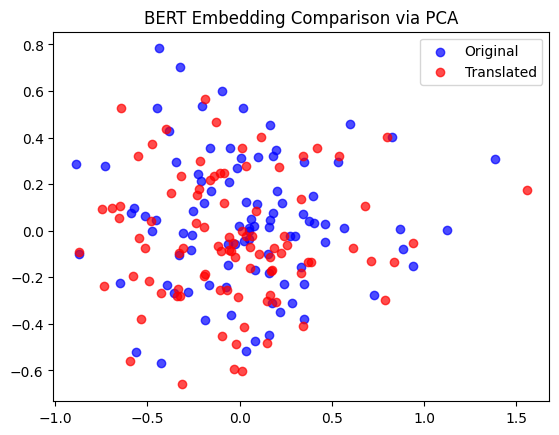

In [59]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

combined_embeddings = torch.cat([original_embeddings, translated_embeddings], dim=0).numpy()
pca = PCA(n_components=2)
reduced_embeddings = pca.fit_transform(combined_embeddings)

# Separate PCA embeddings for original and translated
original_reduced = reduced_embeddings[:len(original_embeddings)]
translated_reduced = reduced_embeddings[len(original_embeddings):]

# Visualize using matplotlib
plt.scatter(original_reduced[:, 0], original_reduced[:, 1], label='Original', alpha=0.7, color='blue')
plt.scatter(translated_reduced[:, 0], translated_reduced[:, 1], label='Translated', alpha=0.7, color='red')
plt.legend()
plt.title('BERT Embedding Comparison via PCA')
plt.show()

***
**MLP After Data augmentation**
***

In [54]:
df = pd.read_csv('translated.csv')
df_copy = df.copy()
df_copy['text'] = df_copy['French_version']
df_doubled = pd.concat([df, df_copy], ignore_index=True)
dataset = Dataset.from_pandas(df_doubled)

In [ ]:
url_groups = defaultdict(list)
for idx, row in enumerate(dataset):
    url_groups[row['URL']].append(idx)

grouped_indices = list(url_groups.values())
random.shuffle(grouped_indices)
num_samples = len(grouped_indices)
train_size = int((1 - 0.4) * num_samples)  # 60% train
valid_size = int(0.4 * 0.5 * num_samples)  # 20% validation
test_size = num_samples - train_size - valid_size  # 20% test

train_indices = [idx for group in grouped_indices[:train_size] for idx in group]
validation_indices = [idx for group in grouped_indices[train_size:train_size + valid_size] for idx in group]
test_indices = [idx for group in grouped_indices[train_size + valid_size:] for idx in group]


train_dataset = dataset.select(train_indices)
validation_dataset = dataset.select(validation_indices)
test_dataset = dataset.select(test_indices)

dataset_dict = DatasetDict({
    'train': train_dataset,
    'validation': validation_dataset,
    'test': test_dataset
})

print(dataset_dict)

DatasetDict({
    train: Dataset({
        features: ['URL', 'Fake News', 'Opinions', 'Subjective', 'Reported information', 'Sources Cited', 'False Information', 'Insinuation', 'Exaggeration', 'Offbeat Title', 'text', 'Title', 'English_version', 'French_version'],
        num_rows: 110
    })
    validation: Dataset({
        features: ['URL', 'Fake News', 'Opinions', 'Subjective', 'Reported information', 'Sources Cited', 'False Information', 'Insinuation', 'Exaggeration', 'Offbeat Title', 'text', 'Title', 'English_version', 'French_version'],
        num_rows: 36
    })
    test: Dataset({
        features: ['URL', 'Fake News', 'Opinions', 'Subjective', 'Reported information', 'Sources Cited', 'False Information', 'Insinuation', 'Exaggeration', 'Offbeat Title', 'text', 'Title', 'English_version', 'French_version'],
        num_rows: 40
    })
})


In [32]:
encoded_dataset.set_format("torch")

In [33]:
pos_counts = df_doubled[labels_name].sum(axis=0).values 
total_samples = len(df_doubled[labels])  # total nuµmber of instances in your dataset
neg_counts = total_samples - pos_counts  # corresponding negative sample counts
pos_weight = neg_counts / (pos_counts + 1e-5)  # adding a small epsilon to avoid division by zero
pos_weight = torch.tensor(pos_weight, dtype=torch.float)

In [34]:
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=10,
    per_device_train_batch_size=4,
    learning_rate=2e-5,
    per_device_eval_batch_size=4,
    eval_strategy="epoch",
    logging_strategy="steps",
    logging_steps=10,
    save_strategy="epoch",
    load_best_model_at_end=True,
)
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=encoded_dataset['train'],
    eval_dataset=encoded_dataset['validation'],
    compute_metrics=compute_metrics,  # Now Trainer will compute our defined metrics
)
trainer.train()

Epoch,Training Loss,Validation Loss,Subset Accuracy
1,0.724200,0.711888,0.000000
2,0.746800,0.708284,0.000000
3,0.736100,0.703431,0.000000
4,0.675600,0.693653,0.000000
5,0.699000,0.682230,0.054054
6,0.767300,0.670238,0.108108
7,0.717200,0.656810,0.162162
8,0.669100,0.646115,0.162162
9,0.691100,0.637318,0.189189
10,0.677200,0.635489,0.189189


TrainOutput(global_step=280, training_loss=0.7045120051928929, metrics={'train_runtime': 1649.6414, 'train_samples_per_second': 0.673, 'train_steps_per_second': 0.17, 'total_flos': 0.0, 'train_loss': 0.7045120051928929, 'epoch': 10.0})

In [ ]:
pred_output = trainer.predict(encoded_dataset['test'])
logits = pred_output.predictions
probabilities = 1 / (1 + np.exp(-logits))
threshold = 0.5
y_pred = (probabilities > threshold).astype(int)
print("Predicted Labels (y_pred) for the validation set:")
print(y_pred)

In [36]:
y_true = encoded_dataset['test']['labels']
micro_f1 = f1_score(y_true, y_pred, average="micro")
macro_f1 = f1_score(y_true, y_pred, average="macro")
ham_loss = hamming_loss(y_true, y_pred)

print("Micro F1 Score:", micro_f1)
print("Macro F1 Score:", macro_f1)
print("Hamming Loss:", ham_loss)

Micro F1 Score: 0.6712328767123288
Macro F1 Score: 0.6183056822443013
Hamming Loss: 0.2807017543859649


In [40]:
torch.save(model.state_dict(), "./saved_model/model_weights.pt")
torch.save({
    "config": model.config if hasattr(model, 'config') else None,
    # Add other metadata if needed
}, "./saved_model/model_config.pt")

print("Model saved successfully!")

Model saved successfully!


***
**Open AI**
***

In [ ]:
results = []
for val in df['text']:
    prompt = f"A partir du text suivant, dont le début est indiqué par les '------', Répond à ces 9 questions suivantes dans l'ordre : 'Le texte est-il une fake news ?', 'L'auteur exprime t-il son opinion ?', 'Le texte contient plus d'opinion que de fait ?', 'l'information contenue dans l'article est rapportée par une autre personne ou source et n'est pas directement approuvée ? Imagine 'Selon le Sénat, il y aura...' par exemple', 'Le texte cite-t-il ses sources ?', 'Le texte contient-il des fausses informations ?', 'Le texte fait des insinuations d'une lecture alternative de la réalité ?', 'Le texte décrit un fait réel mais en exagérant ?', 'Le titre est mensonger par rapport au texte ?'. Répond sous forme de tableau. Voici un exemple de réponses: si tu souhaites répondre non,non,oui,oui,oui,non,non,non,non répond [0,1,1,0,1,0,0,0,0]. Voici quelques exemples : 'Titre : 'mensonge mondial ?' texte : 'Je pense que le covid a été la plus grande maladie de tous les temps, cela a tué des millions de gens' répond [0,1,1,0,0,1,0,1,1]. Les réponses doivent toujours avoir ce format. '--------' : {val}"
    result = make_api_call_to_gpt(prompt)
    results.append(result)

results

In [ ]:
#Go through each value of results, if the first caracter is not '[' then replace the value by '[0,0,0,0,0,0,0,0,0]'
for i in range(len(results)):
    if results[i][0] != '[':
        results[i] = '[0,0,0,0,0,0,0,0,0]'
results


In [ ]:
results_table = []
for result in results:
    result_table = ast.literal_eval(result)
    results_table.append(result_table)
results_table

In [153]:
# Convert results to a DataFrame for comparison
results_df = pd.DataFrame(results_table, columns=labels).astype(int)
correspondence = (df[labels].values == results_df.values).all(axis=1)
percentage_correspondence = correspondence.mean() * 100
print(f"Percentage of correspondence: {percentage_correspondence:.2f}%")

Percentage of correspondence: 8.60%


In [154]:
results_df = pd.DataFrame(results_table, columns=labels).astype(int)
value_comparison = (df[labels].values == results_df.values)
percentage_matching_values = value_comparison.mean() * 100
print(f"Percentage of matching values: {percentage_matching_values:.2f}%")

Percentage of matching values: 76.82%


In [155]:
# Calculate the absolute differences between the two tables
differences = (results_df.values != df[labels].values).sum(axis=0)

# Find the label with the maximum differences
most_different_label = labels_name[np.argmax(differences)]
print(f"The most different label is: {most_different_label}")


The most different label is: Reported information


In [156]:
differences

array([21, 12, 14, 45, 26, 20, 17, 16, 23])